Clone the EEGEmotions repository into a folder not tracked by git.

In this case you can just clone it into the project root since the directory of that repository (`EEGEmotions-27`) has been added to .gitignore.
```shell
git clone https://github.com/huytungst/EEGEmotions-27.git
```

Generate record file sizes of the raw data and save to file.

In [4]:
import numpy as np
from pathlib import Path
import json

data_dir = Path("../EEGEmotions-27/eeg_raw")

signal_lengths = [
    (*(int(i)-1 for i in filepath.name.split(".", 1)[0].split("_", 1)), np.loadtxt(filepath, ndmin=2).shape[0]) for
    filepath in data_dir.glob("*.0.txt")]

with open("signal_lengths.json", "w") as f:
    json.dump(signal_lengths, f)


Load the signal lengths from file.

In [5]:
import json

with open("signal_lengths.json", "r") as f:
    signal_lengths = json.load(f)

signal_lengths = np.array(signal_lengths, dtype=np.float64)

Sort signal lengths by participant ID.

In [6]:
signal_lengths = signal_lengths[np.lexsort((signal_lengths[:, 1], signal_lengths[:, 0]))]

print(signal_lengths)

[[0.000e+00 0.000e+00 6.149e+03]
 [0.000e+00 1.000e+00 4.099e+03]
 [0.000e+00 2.000e+00 3.459e+03]
 ...
 [8.900e+01 2.400e+01 5.380e+03]
 [8.900e+01 2.500e+01 2.435e+03]
 [8.900e+01 2.600e+01 7.814e+03]]


Get video durations and save to file.

In [7]:
from pathlib import Path
import subprocess
import json

video_dir = Path("../EEGEmotions-27/video_clips")

def get_video_duration(path: Path):
    command = [
        "ffprobe",
        "-v", "error",
        "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1",
        path
    ]
    return float(subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT).stdout)

video_durations = [(int(path.name.split(".", 1)[0]) - 1, get_video_duration(path)) for path in video_dir.glob("*.mp4")]

with open("video_durations.json", "w") as f:
    json.dump(video_durations, f)

Load video durations from file.

In [8]:
import json

with open("video_durations.json", "r") as f:
    video_durations = json.load(f)

video_durations_by_emotion_id = np.array(video_durations)

Sort the video durations by the emotion ID and remove the emotion ID so that index serves as ID.

In [9]:
video_durations = video_durations_by_emotion_id[np.argsort(video_durations_by_emotion_id[:, 0])][:,1]

Compute differences from expected EEG signal duration based on the video length.

In [10]:
irrelevant_duration = 10 # 10 seconds of instructions at the beginning of video

expected_durations = video_durations - irrelevant_duration
expected_durations_by_signal = expected_durations[signal_lengths[:,1].astype(int)]

signal_metadata = signal_lengths.copy()
signal_metadata = np.hstack((signal_metadata, expected_durations_by_signal.reshape(-1, 1)))

print(signal_metadata)

[[0.0000000e+00 0.0000000e+00 6.1490000e+03 4.8500000e+01]
 [0.0000000e+00 1.0000000e+00 4.0990000e+03 3.2500000e+01]
 [0.0000000e+00 2.0000000e+00 3.4590000e+03 2.7500000e+01]
 ...
 [8.9000000e+01 2.4000000e+01 5.3800000e+03 4.2583333e+01]
 [8.9000000e+01 2.5000000e+01 2.4350000e+03 1.9125000e+01]
 [8.9000000e+01 2.6000000e+01 7.8140000e+03 6.2041667e+01]]


Save the expected signal length and relative difference as metadata for the signals.

In [11]:
import json

metadata_dict = {
    f"{int(participant_id) + 1}_{int(emotion_id) + 1}.0.txt": {"length": length, "expected_duration": expected_duration}
    for participant_id, emotion_id, length, expected_duration
    in signal_metadata
}

with open("eeg_metadata.json", "w") as f:
    json.dump(metadata_dict, f)

Calculate the expected EEG signal lengths.

In [12]:
expected_eeg_lengths_256hz = expected_durations_by_signal * 256
relative_eeg_lengths_diff_256hz = (signal_lengths[:,2] - expected_eeg_lengths_256hz) / expected_eeg_lengths_256hz

expected_eeg_lengths_128hz = expected_durations_by_signal * 128
relative_eeg_lengths_diff_128hz = (signal_lengths[:,2] - expected_eeg_lengths_128hz) / expected_eeg_lengths_128hz

Make histograms to help visualize the distribution of the data.

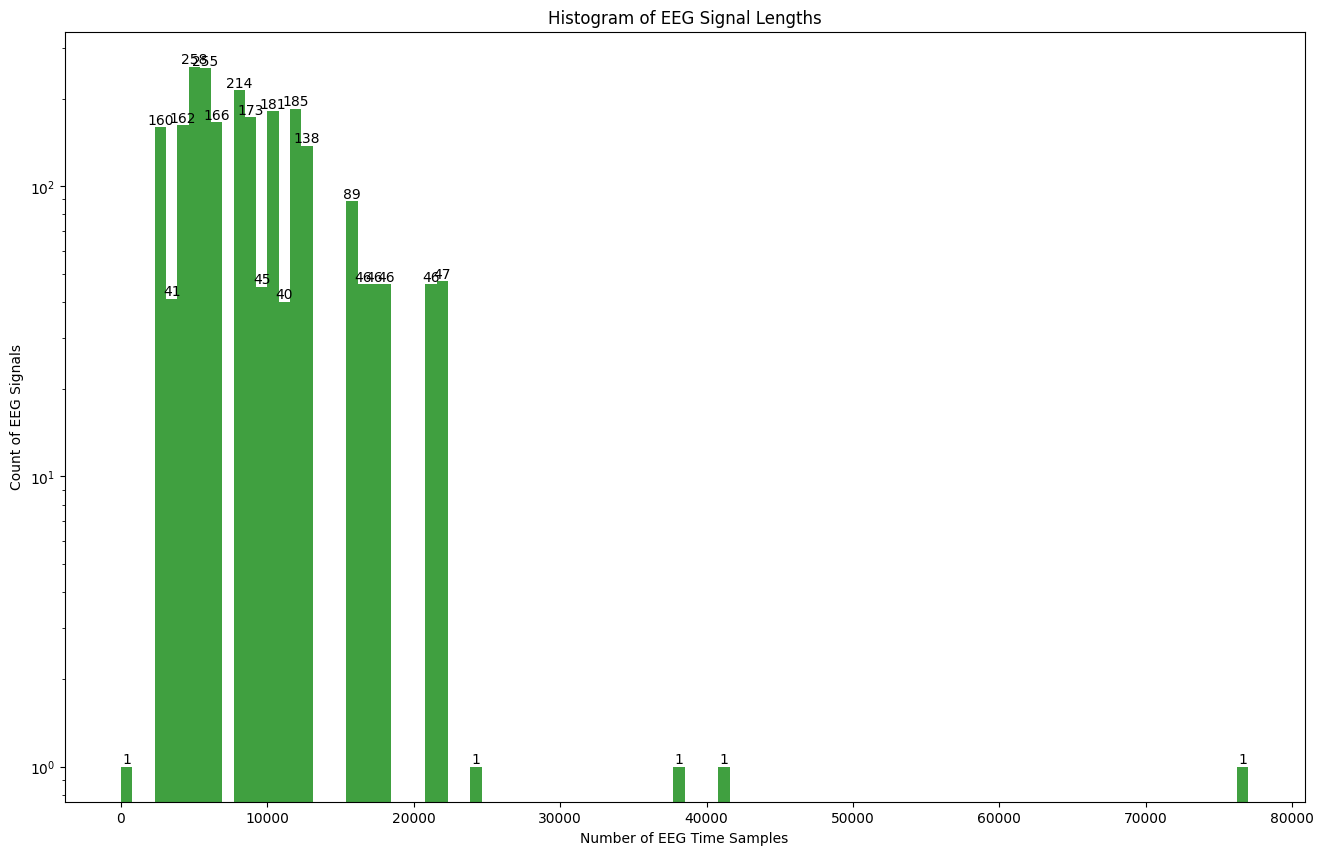

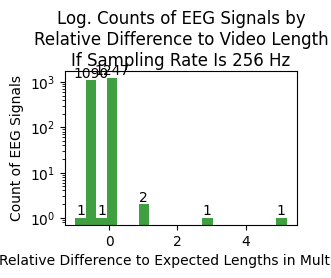

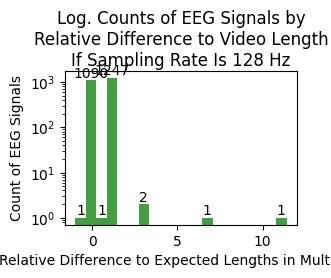

In [38]:
import matplotlib.pyplot as plt

signal_lengths_only = signal_metadata[:, 2]

plt.figure(figsize=(16, 10))
plt.title("Histogram of EEG Signal Lengths")
plt.ylabel("Count of EEG Signals")
plt.xlabel("Number of EEG Time Samples")
counts, bins, patches = plt.hist(signal_lengths_only, 100, facecolor='g', alpha=0.75, log=True)
plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge')

plt.figure(figsize=(3, 2))
plt.xticks(minor=True)
plt.title("Log. Counts of EEG Signals by Relative Difference to Video Length If Sampling Rate Is 256 Hz", wrap=True)
plt.ylabel("Count of EEG Signals")
plt.xlabel("Relative Difference to Expected Lengths in Multiples")
counts, bins, patches = plt.hist(relative_eeg_lengths_diff_256hz, 20, align="mid", facecolor='g', alpha=0.75, log=True)
plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge');

plt.figure(figsize=(3, 2))
plt.xticks(minor=True)
plt.title("Log. Counts of EEG Signals by Relative Difference to Video Length If Sampling Rate Is 128 Hz", wrap=True)
plt.ylabel("Count of EEG Signals")
plt.xlabel("Relative Difference to Expected Lengths in Multiples")
counts, bins, patches = plt.hist(relative_eeg_lengths_diff_128hz, 20, align="mid", facecolor='g', alpha=0.75, log=True)
plt.bar_label(patches, labels=[f'{int(c)}' for c in counts], label_type='edge');

About half of the signals are of the expected length if sampled at 256Hz, but around half are half the size, meaning that they probably have been sampled at half the sampling rate, 128Hz. We want to find out which signal should be removed as outliers while accounting for two possible sampling rates.

In [ ]:
allowed_relative_difference = 0.05

print(f"The allowed difference in sample count is within {allowed_relative_difference * 100:.2f}%")

Show the EEG signals that would be excluded by the allowed relative difference if sampling rate is 256Hz.

In [ ]:
np.hstack(
    (
        signal_metadata.copy(),
        expected_eeg_lengths_256hz.reshape(-1,1),
        relative_eeg_lengths_diff_256hz.reshape(-1,1),
        expected_eeg_lengths_128hz.reshape(-1,1),
        relative_eeg_lengths_diff_128hz.reshape(-1,1),
    )
)[(np.abs(relative_eeg_lengths_diff_256hz) > allowed_relative_difference) & (np.abs(relative_eeg_lengths_diff_128hz) > allowed_relative_difference)]

Export the list of EEG signals to use without the outliers within the allowed relative difference.

In [ ]:
import json

usable_signals = signal_metadata[(np.abs(relative_eeg_lengths_diff_256hz) < allowed_relative_difference) | (np.abs(relative_eeg_lengths_diff_128hz) < allowed_relative_difference)]

usable_signals_list = [
    f"{int(participant_id) + 1}_{int(emotion_id) + 1}.0.txt"
    for participant_id, emotion_id, length, duration
    in usable_signals
]

with open("usable_signals.json", "w") as f:
    json.dump(usable_signals_list, f)